<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab11_FT/blob/develop/SEMANA_11_ALGORITMOS_GEN%C3%89TICOS_Y_EVOLUCI%C3%93N_DE_LA_POBLACI%C3%93N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 11: ALGORITMOS GENÉTICOS Y EVOLUCIÓN DE LA POBLACIÓN**

In [1]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 3.8 MB/s eta 0:00:00


In [21]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

from sklearn import linear_model
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from scipy import stats

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado y escalamiento de datos para las variables numéricas.**

In [4]:
df = pd.read_csv('/content/drive/MyDrive/5.- Quinto Ciclo/2. Mineria de Datos/SEMANA 11/Advertising-1.csv')
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [5]:
## Eliminar valores faltantes
df.dropna(inplace=True)

In [6]:
## Eliminar outliers con Z-score
z_scores = np.abs(stats.zscore(df[['TV', 'Radio', 'Newspaper', 'Sales']]))
df = df[(z_scores < 3).all(axis=1)]

In [7]:
## Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['TV', 'Radio', 'Newspaper']])
X_scaled = pd.DataFrame(X_scaled, columns=['TV', 'Radio', 'Newspaper'])
y = df['Sales']

In [8]:
n_features = 3
verbose = 0

In [18]:
modelo = linear_model.LinearRegression()
modelo.fit(df[['TV', 'Radio', 'Newspaper']], df['Sales'])
modelo

LinearRegression()

## **b. Cree un algoritmo genético para seleccionar las mejores variables para un modelo de regresión lineal incluyendo diversos valores para los parámetros: tamaño de la población, probabilidad de cruce, probabilidad de mutación y número de generaciones**

In [9]:
def calculate_fitness(modelo, x, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    r2_scores = []

    for train_index, test_index in kf.split(x):
        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]
        modelo.fit(x_train, y_train)
        y_pred = modelo.predict(x_test)
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)
    return np.mean(r2_scores)

In [11]:
def evaluate(individual):
  np_ind = np.asarray(individual)
  if np.sum(np_ind) == 0:
    fitness = 0.0
  else:
    feature_idx = np.where(np_ind == 1)[0]
    fitness = calculate_fitness(
        modelo, df.iloc[:, feature_idx].values, df['Sales'].values
        )
  if verbose:
    print("individuo: {} Fitness Score: {}".
          format(individual, fitness))
  return (fitness,)

In [12]:
creator.create("FeatureSelect", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FeatureSelect)
toolbox = base.Toolbox()

In [13]:
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual,toolbox.attr_bool, n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [14]:
toolbox.register("mate", tools.cxTwoPoint) ### Cruce
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05) ### Mutación
toolbox.register("select", tools.selTournament, tournsize=3) ### Selección
toolbox.register("evaluate", evaluate) ### Evaluación

In [15]:
N_POP = 100 ### Tamaño de la población
CX_PB = 0.5 ### Probabilidad de cruce
MUT_PB = 0.2 ### Probabilidad de mutación
N_GEN = 10 ### Cantidad de generaciones

In [16]:
def build_stats(gen, pop, fits):
  record = {}
  length = len(pop)
  mean = sum(fits) / length
  sum2 = sum(x*x for x in fits)
  std = abs(sum2 / length - mean**2)**0.5

  record["gen"] = gen
  record["avg"] = np.mean(fits)
  record["std"] = np.std(fits)
  record["min"] = np.min(fits)
  record["max"] = np.max(fits)

  print("Mínimo: {} Máximo: {} Promedio: {} Desviación: {}"
        .format(min(fits), max(fits), mean, std))
  return record

In [22]:
pop = toolbox.population(n=N_POP)
fitnesses = list(map(toolbox.evaluate, pop))

for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

stats_history = []

for gen in range(N_GEN):
    offspring = algorithms.varAnd(pop, toolbox, cxpb=CX_PB, mutpb=MUT_PB)

    # Evaluar descendencia
    fitnesses = list(map(toolbox.evaluate, offspring))
    for ind, fit in zip(offspring, fitnesses):
        ind.fitness.values = fit

    # Selección de la próxima generación
    pop = toolbox.select(offspring, k=len(pop))

    # Guardar estadísticas
    fits = [ind.fitness.values[0] for ind in pop]
    record = build_stats(gen, pop, fits)
    stats_history.append(record)

Mínimo: 0.027738593753084073 Máximo: 0.8877936847019484 Promedio: 0.7643496638483629 Desviación: 0.20348782216721065
Mínimo: 0.5936946479428437 Máximo: 0.8877936847019484 Promedio: 0.8841838331048131 Desviación: 0.029230067127108256
Mínimo: 0.8840777889822627 Máximo: 0.8877936847019484 Promedio: 0.8877565257447505 Desviación: 0.0003697269593301033
Mínimo: 0.8877936847019484 Máximo: 0.8877936847019484 Promedio: 0.8877936847019474 Desviación: 4.9421560620597e-08
Mínimo: 0.8877936847019484 Máximo: 0.8877936847019484 Promedio: 0.8877936847019474 Desviación: 4.9421560620597e-08
Mínimo: 0.8877936847019484 Máximo: 0.8877936847019484 Promedio: 0.8877936847019474 Desviación: 4.9421560620597e-08
Mínimo: 0.8877936847019484 Máximo: 0.8877936847019484 Promedio: 0.8877936847019474 Desviación: 4.9421560620597e-08
Mínimo: 0.8877936847019484 Máximo: 0.8877936847019484 Promedio: 0.8877936847019474 Desviación: 4.9421560620597e-08
Mínimo: 0.8877936847019484 Máximo: 0.8877936847019484 Promedio: 0.887793684

## **c. Realice un gráfico de la evolución del coeficiente de determinación (R2), seleccione las mejores variables, cree un modelo de regresión lineal con base a estas tomando un 80% de datos para el entrenamiento y mida su desempeño con el R2**

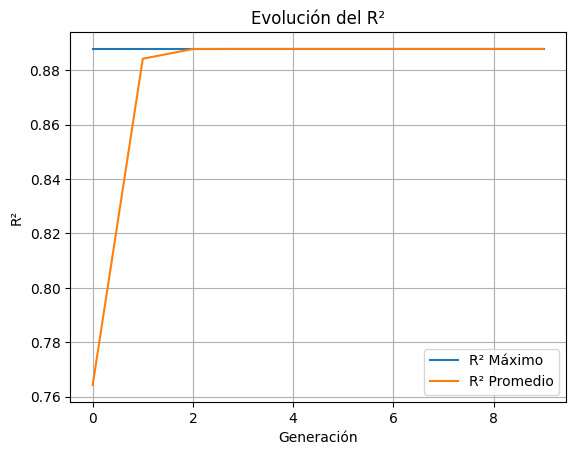

In [23]:
## Grafico de la evolución del coeficiente de determinación (R2)
generations = [record["gen"] for record in stats_history]
max_r2 = [record["max"] for record in stats_history]
avg_r2 = [record["avg"] for record in stats_history]

plt.plot(generations, max_r2, label="R² Máximo")
plt.plot(generations, avg_r2, label="R² Promedio")
plt.xlabel("Generación")
plt.ylabel("R²")
plt.title("Evolución del R²")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
## Seleción de mejores variables
best_ind = tools.selBest(pop, k=1)[0]
print("Mejor individuo:", best_ind)

selected_features = np.where(np.array(best_ind) == 1)[0]
feature_names = X_scaled.columns[selected_features]

print("Variables seleccionadas:", feature_names.tolist())

Mejor individuo: [1, 1, 0]
Variables seleccionadas: ['TV', 'Radio']


In [25]:
# Crear modelo final
from sklearn.model_selection import train_test_split

X_selected = X_scaled.iloc[:, selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

modelo_final = linear_model.LinearRegression()
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

r2_final = r2_score(y_test, y_pred)
print("R² del modelo final:", r2_final)

R² del modelo final: 0.9028883880054271
